In [1]:
!pip install -q opendatasets librosa scikit-learn


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [3]:
#Download Dataset
!pip install -q kaggle
from google.colab import files
uploaded = files.upload()  # upload your kaggle.json


Saving kaggle.json to kaggle.json


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d chrisfilo/urbansound8k
!unzip -q urbansound8k.zip -d /content/
!rm -f urbansound8k.zip


Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.61G/5.61G [00:33<00:00, 177MB/s]



In [5]:
#Load metadata and Build fold respecting-splits
import pandas as pd
from sklearn.model_selection import train_test_split

metadata_path = "/content/UrbanSound8K.csv"
data_df = pd.read_csv(metadata_path)

class_names = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark", "drilling",
    "engine_idling", "gun_shot", "jackhammer", "siren", "street_music"
]

development_df = data_df[data_df["fold"].isin(range(1, 10))].reset_index(drop=True)
test_df = data_df[data_df["fold"] == 10].reset_index(drop=True)

train_df, val_df = train_test_split(
    development_df,
    test_size=0.15,
    stratify=development_df["classID"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test (fold10, untouched):", len(test_df))


Train: 6710  Val: 1185  Test (fold10, untouched): 837


## Dataset with fixed-range dB normalization + SpecAugment

**Normalization change:** instead of rescaling each clip to its own min/max (which erases relative
loudness differences between classes and between samples), we clip the dB spectrogram to a
fixed, physically meaningful range `[-80, 0]` dB and linearly map that fixed range to `[0, 1]`.
Every clip is normalized the same way, so a quiet class and a loud class stay numerically distinguishable.

**SpecAugment:** applied only when `train=True`. Two operations, each done on the already-normalized
spectrogram tensor:
- *Frequency masking*: zero out a contiguous random band of `n_mels` rows (simulates missing/attenuated frequency content).
- *Time masking*: zero out a contiguous random band of time columns (simulates the sound not being present in a segment, or occlusion by transient noise).

Masking with the array's own low value (0, since we normalized to [0,1]) is a standard, safe choice —
it doesn't change the sound's class identity, only forces the network not to over-rely on any single
time/frequency slice. Kept conservative (small mask widths, one mask per axis) since this is our first
augmentation experiment.

In [6]:
import librosa

TARGET_SR = 22050
TARGET_DURATION = 4
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

DB_MIN, DB_MAX = -80.0, 0.0  # fixed reference range for normalization


def spec_augment(spec, freq_mask_param=12, time_mask_param=20, num_freq_masks=1, num_time_masks=1):
    """spec: torch.FloatTensor of shape (n_mels, time), values already in [0, 1]."""
    spec = spec.clone()
    n_mels, n_frames = spec.shape

    for _ in range(num_freq_masks):
        f = random.randint(0, freq_mask_param)
        if f == 0 or f >= n_mels:
            continue
        f0 = random.randint(0, n_mels - f)
        spec[f0:f0 + f, :] = 0.0

    for _ in range(num_time_masks):
        t = random.randint(0, time_mask_param)
        if t == 0 or t >= n_frames:
            continue
        t0 = random.randint(0, n_frames - t)
        spec[:, t0:t0 + t] = 0.0

    return spec


class UrbanSoundDataset(Dataset):
    def __init__(self, dataframe, audio_root="/content", train=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_root = audio_root
        self.train = train  # controls whether SpecAugment is applied

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        audio_path = f"{self.audio_root}/fold{row['fold']}/{row['slice_file_name']}"

        signal, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
        signal = librosa.util.fix_length(signal, size=TARGET_SAMPLES)

        mel_spec = librosa.feature.melspectrogram(
            y=signal, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
        )
        # Fixed-range dB conversion + normalization (Experiment 1 fix)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_db = np.clip(mel_db, DB_MIN, DB_MAX)
        mel_norm = (mel_db - DB_MIN) / (DB_MAX - DB_MIN)  # -> [0, 1], fixed scale for every clip

        spec_tensor = torch.tensor(mel_norm, dtype=torch.float32)

        if self.train:
            spec_tensor = spec_augment(spec_tensor)

        spec_tensor = spec_tensor.unsqueeze(0)  # (1, n_mels, time)
        label = int(row["classID"])
        return spec_tensor, label


In [7]:
#DataLoaders
BATCH_SIZE = 32

train_dataset = UrbanSoundDataset(train_df, train=True)   # augmentation ON
val_dataset = UrbanSoundDataset(val_df, train=False)       # augmentation OFF
test_dataset = UrbanSoundDataset(test_df, train=False)     # augmentation OFF, untouched until final eval

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), " Val batches:", len(val_loader), " Test batches:", len(test_loader))


Train batches: 210  Val batches: 38  Test batches: 27


## Model: BatchNorm CNN

Same overall depth as your baseline (3 conv blocks -> GAP -> FC) so the comparison against
Experiment 0 isolates the effect of BatchNorm + training regime + augmentation, not capacity.

`Conv2D -> BatchNorm2D -> ReLU -> MaxPool -> Dropout`, repeated 3x.

**Why BatchNorm helps here:** it normalizes each channel's activations to zero mean / unit variance
(with learned scale/shift) *per mini-batch*, which keeps gradients well-scaled through the network as
training progresses. Practically, this lets you use a higher effective learning rate, converge faster,
and reduces sensitivity to the exact initialization — all of which matter more once SpecAugment injects
noise into every training batch.

In [8]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


model = AudioCNN(num_classes=10).to(device)
print(model)


AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.3, inplace=False)
  )
  (pool): A

## Loss (weighted CE, from training folds only), optimizer, scheduler

- **AdamW** decouples weight decay from the gradient update (unlike Adam, where L2 regularization
  gets mixed into the adaptive learning-rate calculation) — this gives more predictable, effective
  regularization.
- **ReduceLROnPlateau** watches validation Macro-F1: if it stops improving for `patience` epochs, the
  LR is cut by `factor`. This lets the model take large steps early and fine-tune later, without you
  having to hand-pick a decay schedule.

In [11]:
num_classes = 10
class_counts = train_df["classID"].value_counts().sort_index()
class_weights = len(train_df) / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
)

print("Class weights:\n", class_weights)


Class weights:
 classID
0    0.877124
1    1.997024
2    0.877124
3    0.877124
4    0.877124
5    0.870298
6    2.305842
7    0.873698
8    0.933241
9    0.877124
Name: count, dtype: float64


## Train / evaluate functions (track loss, accuracy, Macro-F1)

In [12]:
from sklearn.metrics import f1_score, precision_recall_fscore_support


def run_epoch(model, dataloader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1


In [13]:
NUM_EPOCHS = 18
PATIENCE = 5
CHECKPOINT_PATH = "/content/best_audio_cnn_specaugment.pth"

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_f1": [], "lr": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, device, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, device, optimizer=None)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss {train_loss:.4f} acc {train_acc:.2f}% | "
        f"val_loss {val_loss:.4f} acc {val_acc:.2f}% f1 {val_f1:.4f} | "
        f"lr {current_lr:.2e}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_acc,
            "val_macro_f1": val_f1,
        }, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}. Best epoch was {best_epoch} (val Macro-F1 {best_val_f1:.4f}).")
        break

print(f"\nBest epoch: {best_epoch} | Best validation Macro-F1: {best_val_f1:.4f}")


Epoch 01/18 | train_loss 1.9978 acc 21.40% | val_loss 1.8525 acc 28.35% f1 0.2289 | lr 1.00e-03
Epoch 02/18 | train_loss 1.7901 acc 29.06% | val_loss 1.7086 acc 33.76% f1 0.3085 | lr 1.00e-03
Epoch 03/18 | train_loss 1.6258 acc 34.28% | val_loss 1.6546 acc 37.89% f1 0.3267 | lr 1.00e-03
Epoch 04/18 | train_loss 1.5190 acc 37.62% | val_loss 1.4721 acc 39.16% f1 0.3904 | lr 1.00e-03
Epoch 05/18 | train_loss 1.4524 acc 41.80% | val_loss 1.3823 acc 44.89% f1 0.4469 | lr 1.00e-03
Epoch 06/18 | train_loss 1.3968 acc 43.92% | val_loss 1.9213 acc 31.65% f1 0.2957 | lr 1.00e-03
Epoch 07/18 | train_loss 1.3684 acc 45.11% | val_loss 1.3311 acc 48.10% f1 0.4745 | lr 1.00e-03
Epoch 08/18 | train_loss 1.3244 acc 47.57% | val_loss 1.4079 acc 41.18% f1 0.4260 | lr 1.00e-03
Epoch 09/18 | train_loss 1.2884 acc 49.09% | val_loss 1.4949 acc 42.19% f1 0.3974 | lr 1.00e-03
Epoch 10/18 | train_loss 1.2659 acc 49.96% | val_loss 1.3128 acc 51.73% f1 0.5164 | lr 1.00e-03
Epoch 11/18 | train_loss 1.2258 acc 51.5

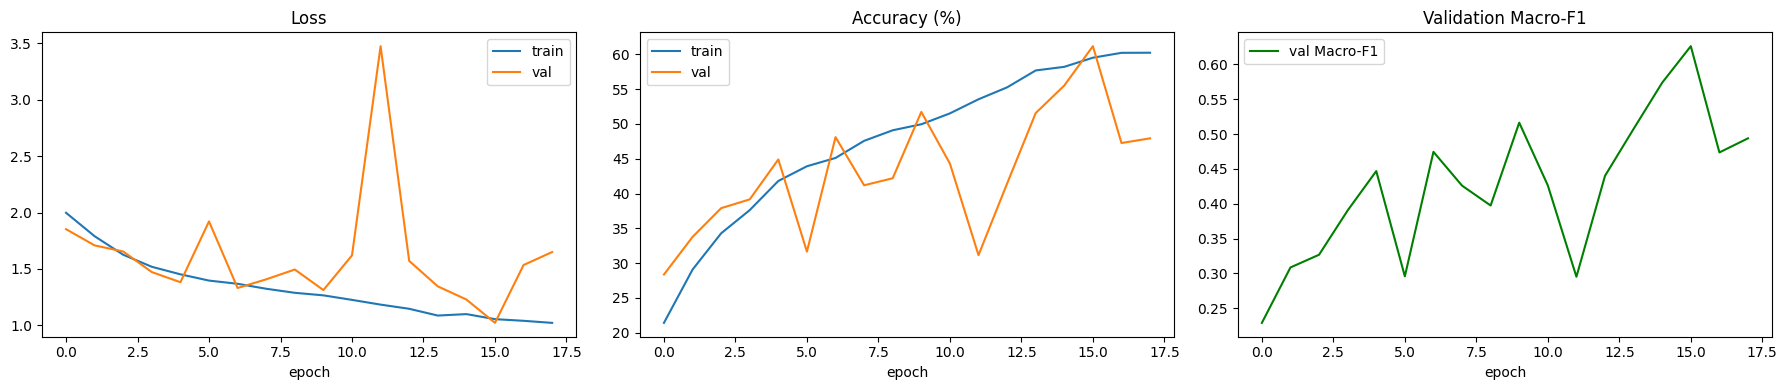

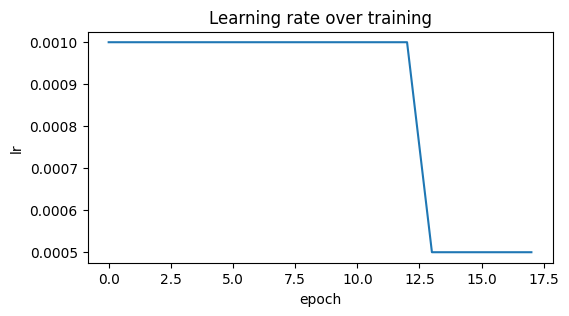

In [14]:
#Plot training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("epoch"); axes[1].legend()

axes[2].plot(history["val_f1"], label="val Macro-F1", color="green")
axes[2].set_title("Validation Macro-F1"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(history["lr"])
plt.title("Learning rate over training")
plt.xlabel("epoch"); plt.ylabel("lr")
plt.show()


In [16]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

print("Restored epoch:", checkpoint["epoch"])
print("Val accuracy at that epoch:", checkpoint["val_accuracy"])
print("Val Macro-F1 at that epoch:", checkpoint["val_macro_f1"])

Restored epoch: 16
Val accuracy at that epoch: 61.18143459915611
Val Macro-F1 at that epoch: 0.6262426264058993


Test Loss: 1.0347 | Test Accuracy: 61.77% | Test Macro-F1: 0.6048

Classification Report:

                  precision    recall  f1-score   support

 air_conditioner     0.3950    0.4700    0.4292       100
        car_horn     0.7143    0.7576    0.7353        33
children_playing     0.6180    0.5500    0.5820       100
        dog_bark     0.7021    0.6600    0.6804       100
        drilling     0.7073    0.5800    0.6374       100
   engine_idling     0.7264    0.8280    0.7739        93
        gun_shot     0.3168    1.0000    0.4812        32
      jackhammer     0.6905    0.9062    0.7838        96
           siren     0.9333    0.1687    0.2857        83
    street_music     0.8000    0.5600    0.6588       100

        accuracy                         0.6177       837
       macro avg     0.6604    0.6480    0.6048       837
    weighted avg     0.6777    0.6177    0.6086       837



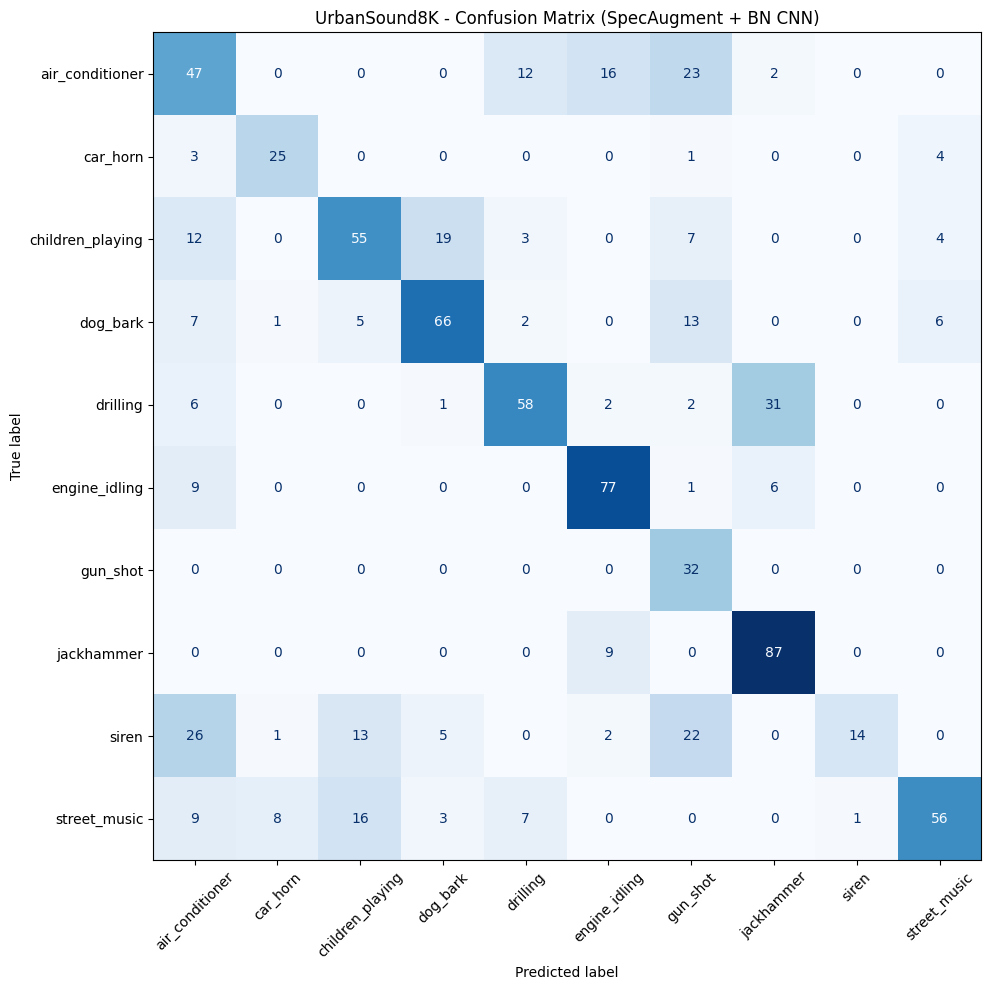

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion, device, optimizer=None)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}% | Test Macro-F1: {test_f1:.4f}")

model.eval()
all_predictions, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("UrbanSound8K - Confusion Matrix (SpecAugment + BN CNN)")
plt.tight_layout()
plt.show()
